In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Get_hydrophobicity)=
# Get hydrophobicity

*Evaluating amino acid hydrophobicity scores from standard biochemical scales.*

The function {func}`molsysmt.physchem.get_hydrophobicity` assigns hydrophobicity indices per residue using 15 published experimental and statistical scales:
- `'eisenberg'`: Consensus normalized scale from Eisenberg et al. (1984).
- `'kyte'`: Hydropathy index from Kyte & Doolittle (1982).
- `'chothia'`: Transfer free energy scale from Chothia (1976).
- `'black'`: Hydrophobicity scale from Black & Mould (1991).
- `'wolfenden'`: Free energy of vapor-to-water transfer from Wolfenden et al. (1979).
- `'rao'`: Rao & Argos (1986).
- `'sweet'`: Sweet & Eisenberg (1983).
- `'abraham'`: Abraham & Leo (1987).
- `'bull'`: Bull & Breese (1974).
- `'guy'`: Guy (1985).
- `'miyazawa'`: Miyazawa & Jernigan (1985).
- `'roseman'`: Roseman (1988).
- `'hopp'`: Hopp & Woods (1981).
- `'manavalan'`: Manavalan & Ponnuswamy (1978).
- `'fauchere'`: Fauchère & Pliška (1983).

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.physchem.get_hydrophobicity`.
:::


## Basic usage

By default (`definition='eisenberg'`), the consensus hydrophobicity values are returned for each residue:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['Trp-Cage']['1l2y.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We query the Eisenberg hydrophobicity scores and plot the sequence profile:


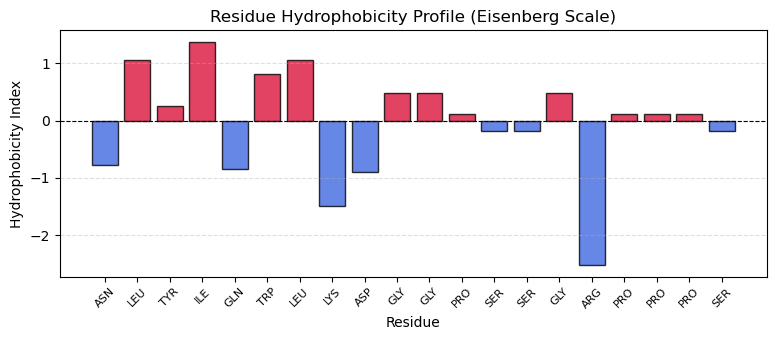

In [4]:
hp = msm.physchem.get_hydrophobicity(molsys, element='group', definition='eisenberg')
group_names = msm.get(molsys, element='group', name=True)

fig, ax = plt.subplots(figsize=(8, 3.5))
colors = ['crimson' if val > 0 else 'royalblue' for val in hp]
ax.bar(range(len(hp)), hp, color=colors, edgecolor='black', alpha=0.8)
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_xticks(range(len(hp)))
ax.set_xticklabels(group_names, rotation=45, fontsize=8)
ax.set_title('Residue Hydrophobicity Profile (Eisenberg Scale)')
ax.set_xlabel('Residue')
ax.set_ylabel('Hydrophobicity Index')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()


## Alternative hydrophobicity scales

Users can choose other established scales depending on the physical context (e.g. `definition='kyte'`, `definition='chothia'`, `definition='black'`, `definition='wolfenden'`):


In [5]:
hp_kyte = msm.physchem.get_hydrophobicity(molsys, element='group', definition='kyte')
hp_chothia = msm.physchem.get_hydrophobicity(molsys, element='group', definition='chothia')
hp_black = msm.physchem.get_hydrophobicity(molsys, element='group', definition='black')
hp_wolfenden = msm.physchem.get_hydrophobicity(molsys, element='group', definition='wolfenden')

print('Kyte & Doolittle (first 5):', hp_kyte[:5])
print('Chothia scale (first 5):', hp_chothia[:5])
print('Black scale (first 5):', hp_black[:5])
print('Wolfenden scale (first 5):', hp_wolfenden[:5])


Kyte & Doolittle (first 5): [-3.5  3.8 -1.3  4.5 -3.5]
Chothia scale (first 5): [0.12 0.45 0.15 0.6  0.07]
Black scale (first 5): [0.236 0.943 0.88  0.943 0.251]
Wolfenden scale (first 5): [-9.68  2.28 -6.11  2.15 -9.38]


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query residue names and attributes with {func}`molsysmt.basic.get`.
- {ref}`Get polarity <Tutorial_Get_polarity>`: Query residue polarities with {func}`molsysmt.physchem.get_polarity`.
- {ref}`Get transmembrane tendency <Tutorial_Get_transmembrane_tendency>`: Query transmembrane propensities with {func}`molsysmt.physchem.get_transmembrane_tendency`.
:::
